In [83]:
! pip install scikit-learn
! pip install dask
! pip install pandas matplotlib seaborn scikit-learn
! pip list
! pip install dash


Package                   Version
------------------------- --------------
anyio                     4.9.0
argon2-cffi               23.1.0
argon2-cffi-bindings      21.2.0
arrow                     1.3.0
asttokens                 3.0.0
async-lru                 2.0.5
attrs                     25.3.0
babel                     2.17.0
beautifulsoup4            4.13.4
bleach                    6.2.0
blinker                   1.9.0
certifi                   2025.4.26
cffi                      1.17.1
charset-normalizer        3.4.2
click                     8.2.1
cloudpickle               3.1.1
colorama                  0.4.6
comm                      0.2.2
contourpy                 1.3.2
cycler                    0.12.1
dash                      3.0.4
dask                      2025.5.1
debugpy                   1.8.14
decorator                 5.2.1
defusedxml                0.7.1
executing                 2.2.0
fastjsonschema            2.21.1
Flask                     3.0.3
fonttools    

In [5]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, mean_squared_error

In [ ]:
file_path = r"C:\Users\Shivani\Downloads\Shipment_Dataset.csv"
df = pd.read_csv(file_path) 

In [14]:
# Overview of data
df.info()
df.describe()

# Handling missing values
df = df.dropna()  # or use imputation as needed

# Convert 'Date of Shipment' to datetime
df['Date of Shipment'] = pd.to_datetime(df['Date of Shipment'], errors='coerce')

# Remove duplicates
df = df.drop_duplicates()

# Derive new column: Shipping Duration (example using Dispatch and Delivery columns)
#df['Shipping Duration'] = (pd.to_datetime(df['Delivery Date']) - pd.to_datetime(df['Dispatch Date'])).dt.days

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 28 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Shipment ID                   50000 non-null  object 
 1   Company Name                  50000 non-null  object 
 2   Source Location               50000 non-null  object 
 3   Destination Location          50000 non-null  object 
 4   Source Latitude               50000 non-null  float64
 5   Source Longitude              50000 non-null  float64
 6   Destination Latitude          50000 non-null  float64
 7   Destination Longitude         50000 non-null  float64
 8   Distance (km)                 50000 non-null  float64
 9   Category                      50000 non-null  object 
 10  No. of Items                  50000 non-null  int64  
 11  Package Weight (kg)           50000 non-null  float64
 12  Package Volume (cc)           50000 non-null  float64
 13  P

In [15]:
print(df['Date of Shipment'])

0       2023-05-11
1       2023-02-28
3       2023-09-21
4       2023-02-13
5       2023-08-01
           ...    
49993   2023-12-05
49994   2023-12-07
49997   2023-05-23
49998   2023-08-25
49999   2023-02-09
Name: Date of Shipment, Length: 32994, dtype: datetime64[ns]


In [16]:
df['Cost_per_km'] = df['Shipment Cost (in Rs.)'] / df['Distance (km)']
df['Cost_per_kg'] = df['Shipment Cost (in Rs.)'] / df['Package Weight (kg)']
df['Is_Delayed'] = df['Delay (hrs)'] > 0

# Delay Category
df['Delay_Category'] = pd.cut(df['Delay (hrs)'], bins=[-1, 1, 5, np.inf], labels=['Low', 'Medium', 'High'])

# Complex Feature: Fragile & High Value (example logic)
df['Is_Fragile_High_Value'] = (df['Fragile'] == 1) & (df['Shipment Cost (in Rs.)'] > df['Shipment Cost (in Rs.)'].quantile(0.75))

In [17]:
# IQR method for Profit
Q1 = df['Profit (in Rs.)'].quantile(0.25)
Q3 = df['Profit (in Rs.)'].quantile(0.75)
IQR = Q3 - Q1
df = df[(df['Profit (in Rs.)'] >= Q1 - 1.5 * IQR) & (df['Profit (in Rs.)'] <= Q3 + 1.5 * IQR)]

In [18]:
df.to_csv('output.csv', index=False)

In [19]:
df = df.drop_duplicates()

Text(0.5, 1.0, 'Delay Boxplot')

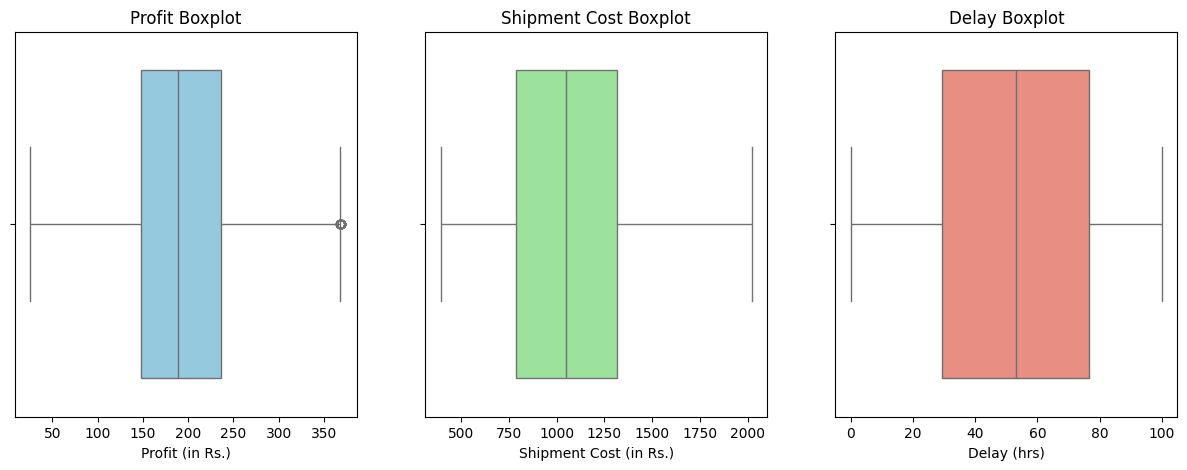

In [20]:
plt.figure(figsize=(15, 5))

# Profit Boxplot
plt.subplot(1, 3, 1)
sns.boxplot(x=df['Profit (in Rs.)'], color='skyblue')
plt.title('Profit Boxplot')

# Cost Boxplot
plt.subplot(1, 3, 2)
sns.boxplot(x=df['Shipment Cost (in Rs.)'], color='lightgreen')
plt.title('Shipment Cost Boxplot')

# Delay Boxplot
plt.subplot(1, 3, 3)
sns.boxplot(x=df['Delay (hrs)'], color='salmon')
plt.title('Delay Boxplot')

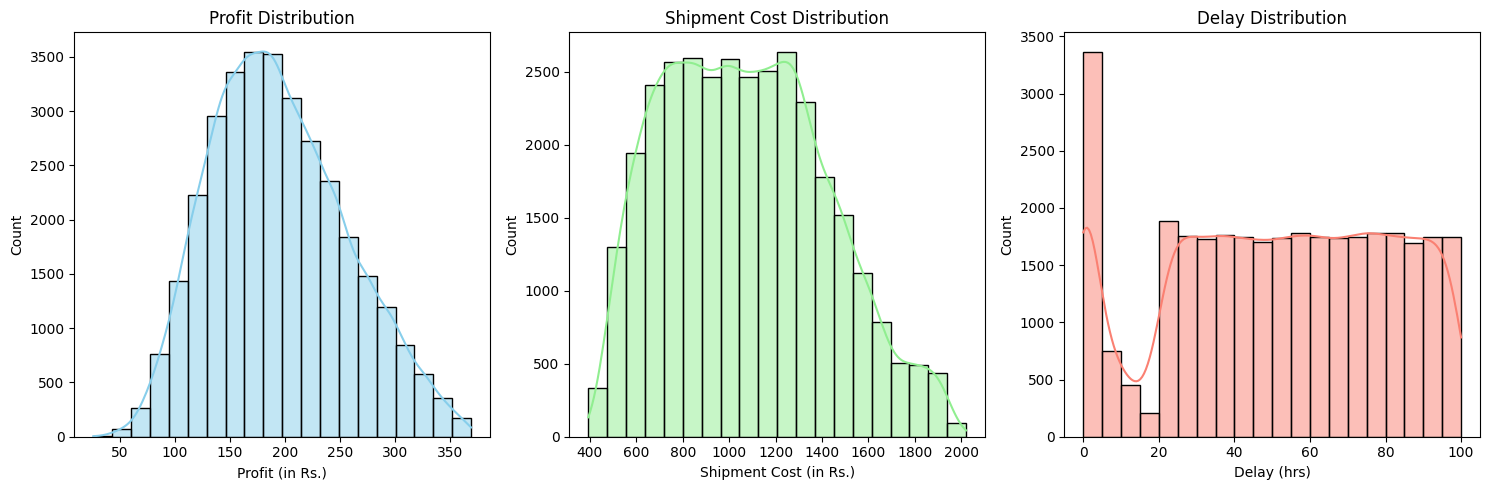

In [21]:
# Plot histograms for Profit(in Rs.),Shipment Cost (in Rs.), Delay(hrs)
plt.figure(figsize=(15, 5))

# Profit Histogram
plt.subplot(1, 3, 1)
sns.histplot(df['Profit (in Rs.)'], bins=20, kde=True, color='skyblue')
plt.title('Profit Distribution')

# Cost Histogram
plt.subplot(1, 3, 2)
sns.histplot(df['Shipment Cost (in Rs.)'], bins=20, kde=True, color='lightgreen')
plt.title('Shipment Cost Distribution')
# Delay Histogram
plt.subplot(1, 3, 3)
sns.histplot(df['Delay (hrs)'], bins=20, kde=True, color='salmon')
plt.title('Delay Distribution')

plt.tight_layout()
plt.show()

In [22]:
print(df['Company Name'].value_counts())

Company Name
FedEx        8253
DHL          6611
UPS          6584
Delhivery    6508
BlueDart     4893
Name: count, dtype: int64


<Axes: xlabel='Package Cost (in Rs.)', ylabel='Profit (in Rs.)'>

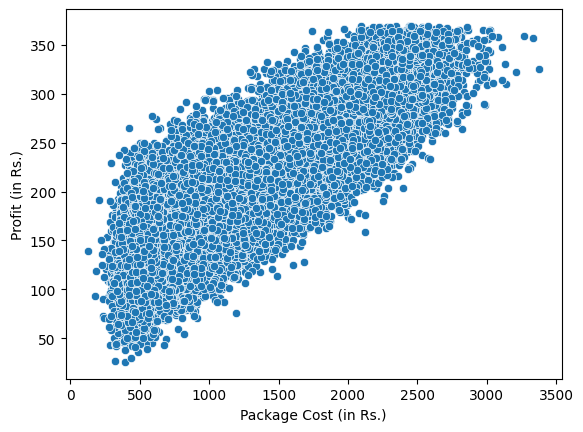

In [23]:
# Scatter plot between cost and profit
sns.scatterplot(data=df, x='Package Cost (in Rs.)', y='Profit (in Rs.)')

<Axes: xlabel='Shipment Mode', ylabel='Delay (hrs)'>

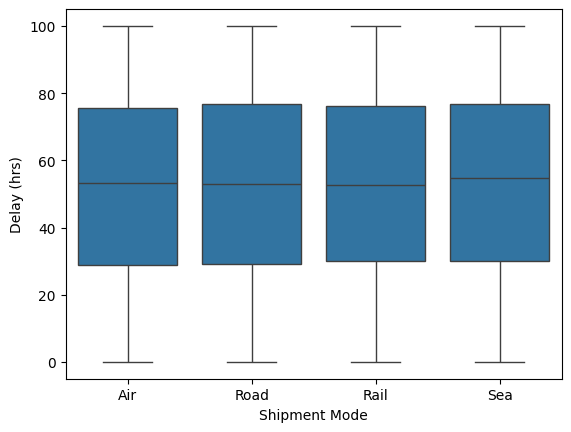

In [24]:
# Boxplot of delay by shipment mode
sns.boxplot(x='Shipment Mode', y='Delay (hrs)', data=df)


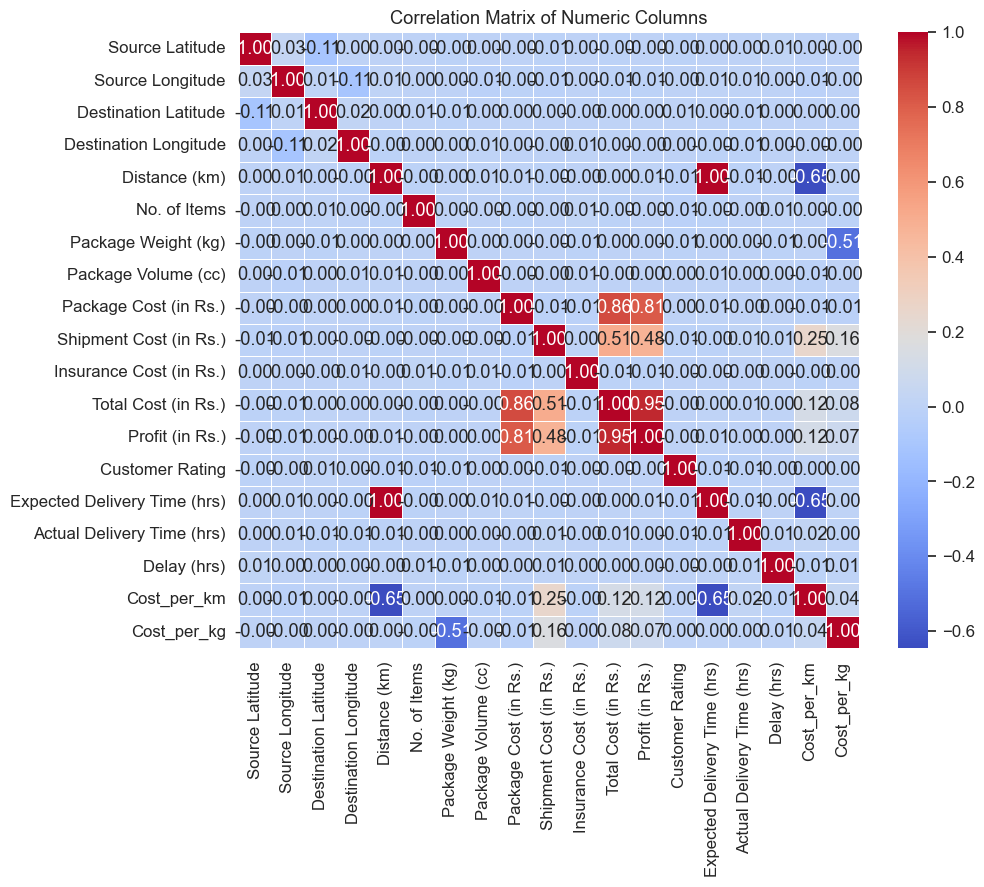

In [25]:
# Optional: Improve plot appearance
sns.set(style="whitegrid", font_scale=1.1)

# Step 1: Select only numeric columns
numeric_df = df.select_dtypes(include=['int64', 'float64'])

# Step 2: Compute the correlation matrix
corr_matrix = numeric_df.corr()

# Step 3: Plot the correlation matrix using a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix of Numeric Columns')
plt.show()

In [26]:
from sklearn.preprocessing import StandardScaler

# Recheck the column names before encoding
categorical_cols = ['Shipment Mode', 'Shipment Priority', 'Company Name']
for col in categorical_cols:
    if col not in df.columns:
        print(f"Warning: Column '{col}' not found in DataFrame!")

# Encoding categorical variables (only those that exist)
df_encoded = pd.get_dummies(df, columns=[col for col in categorical_cols if col in df.columns], drop_first=True)

# Define numerical columns to scale (only scale if present)
scale_cols = ['Package Weight (kg)', 'Distance (km)', 'Shipment Cost (in Rs.)', 'Profit (in Rs.)']
scale_cols_present = [col for col in scale_cols if col in df_encoded.columns]

# Apply Standard Scaling
scaler = StandardScaler()
df_encoded[scale_cols_present] = scaler.fit_transform(df_encoded[scale_cols_present])

In [43]:
# Ensure 'Cost per km' column exists
if 'Cost per km' not in df.columns:
    df['Cost per km'] = df['Shipment Cost (in Rs.)'] / df['Distance (km)']

# Group by actual company name
if 'Company Name' in df.columns:
    cost_eff = df.groupby('Company Name')['Cost per km'].mean().sort_values()
    print("✅ Cost-efficient companies (lowest cost per km):")
    print(cost_eff.head())
else:
    print("❌ Column 'Company Name' not found. Please use original DataFrame before encoding.")


# Top regions with highest costs
region_cost = df.groupby('Source Location')['Total Cost (in Rs.)'].mean().sort_values(ascending=False)
print("Regions with highest average logistics costs:\n", region_cost.head())

# Product categories with most delays
category_delay = df.groupby('Category')['Delay (hrs)'].mean().sort_values(ascending=False)
print("Categories with most delivery delays:\n", category_delay)


✅ Cost-efficient companies (lowest cost per km):
Company Name
FedEx        1.248438
Delhivery    1.255669
BlueDart     1.256575
DHL          1.260019
UPS          1.286278
Name: Cost per km, dtype: float64
Regions with highest average logistics costs:
 Source Location
Ahmedabad    2081.337213
Mumbai       2068.955695
Chennai      2067.819157
Bangalore    2066.325881
Hyderabad    2063.424236
Name: Total Cost (in Rs.), dtype: float64
Categories with most delivery delays:
 Category
Furniture      47.018933
Documents      46.779252
Electronics    46.775124
Medicines      46.428751
Apparel        46.222744
Name: Delay (hrs), dtype: float64


In [68]:
# Convert date column
df['Date of Shipment'] = pd.to_datetime(df['Date of Shipment'])

# --- 1. DESCRIPTIVE ANALYTICS ---

# Average shipment cost by company and mode
avg_cost = df.groupby(['Company Name', 'Shipment Mode'])['Shipment Cost (in Rs.)'].mean().reset_index()
print("Average shipment cost by Company and Mode:\n", avg_cost)




# Top 5 most common shipment routes
if 'Origin' in df.columns and 'Destination' in df.columns:
    df['Route'] = df['Origin'] + " -> " + df['Destination']
    top_routes = df['Route'].value_counts().head(5)
    print("\nTop 5 Shipment Routes:")
    print(top_routes)

# Distribution of delays across companies
if 'Delayed' in df.columns:
    delay_distribution = df[df['Delayed'] == 'Yes'].groupby('Company').size()
    print("\nDelay Distribution by Company:")
    print(delay_distribution)

    # Visualization
    delay_distribution.plot(kind='bar', title='Delays by Company')
    plt.ylabel('Number of Delayed Shipments')
    plt.show()

# Shipments returned or delayed per month
if 'Status' in df.columns and 'Shipment_Date' in df.columns:
    df['Shipment_Date'] = pd.to_datetime(df['Shipment_Date'])
    df['Month'] = df['Shipment_Date'].dt.to_period('M')

    monthly_issues = df[df['Status'].isin(['Returned', 'Delayed'])].groupby(['Month', 'Status']).size().unstack().fillna(0)
    print("\nReturned or Delayed Shipments per Month:")
    print(monthly_issues)

    # Visualization
    monthly_issues.plot(kind='bar', stacked=True, figsize=(10, 6), title='Returned/Delayed Shipments Per Month')
    plt.ylabel('Number of Shipments')
    plt.tight_layout()
    plt.show()

Average shipment cost by Company and Mode:
    Company Name Shipment Mode  Shipment Cost (in Rs.)
0      BlueDart           Air             1070.322874
1      BlueDart          Rail             1085.610169
2      BlueDart          Road             1074.538162
3      BlueDart           Sea             1071.763460
4           DHL           Air             1070.685818
5           DHL          Rail             1088.497683
6           DHL          Road             1070.001356
7           DHL           Sea             1070.950810
8     Delhivery           Air             1063.216153
9     Delhivery          Rail             1069.552404
10    Delhivery          Road             1076.727163
11    Delhivery           Sea             1070.404420
12        FedEx           Air             1074.793674
13        FedEx          Rail             1070.975673
14        FedEx          Road             1073.013453
15        FedEx           Sea             1069.665550
16          UPS           Air         

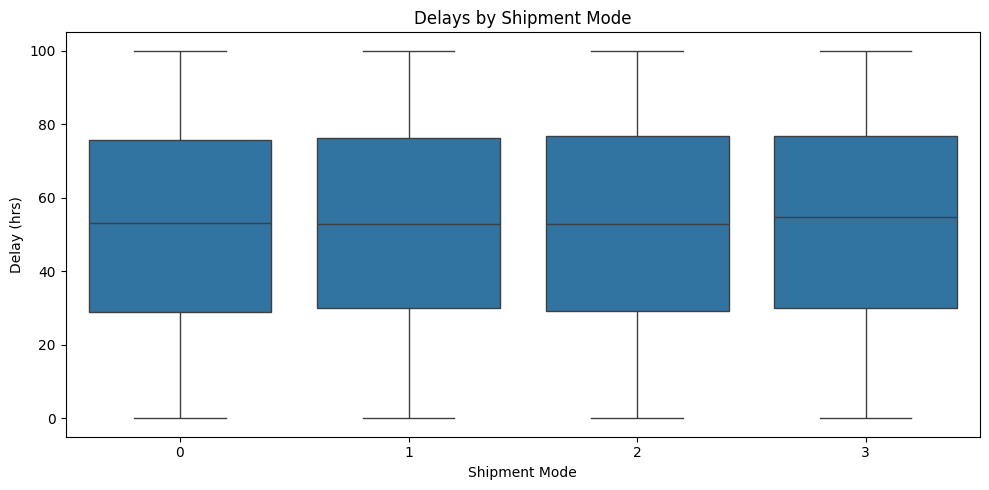

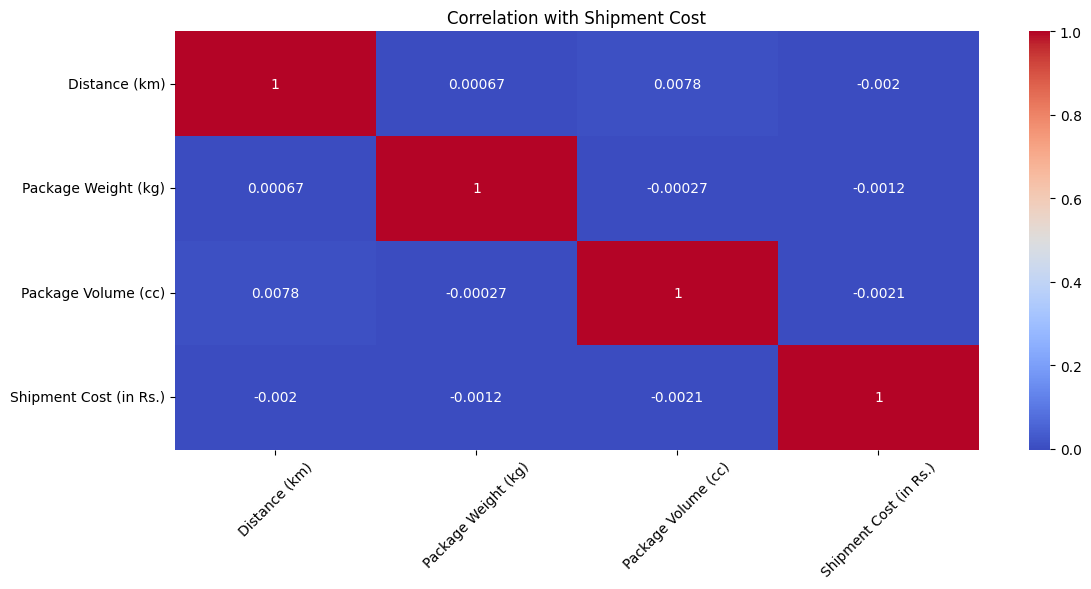

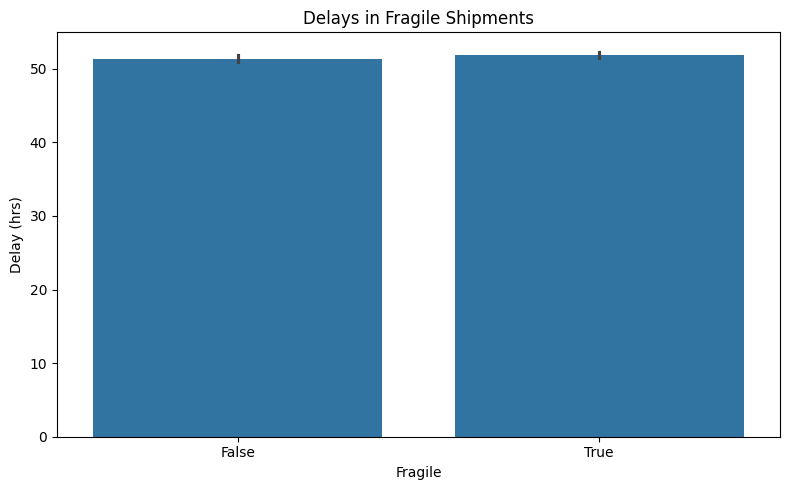

In [4]:
# -------------------- DIAGNOSTIC ANALYTICS --------------------
# 1. Delays by City and Mode
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='Shipment Mode', y='Delay (hrs)')
plt.title('Delays by Shipment Mode')
plt.tight_layout()
plt.savefig('delays_by_mode.png')

# 2. Profit per Shipment by Company
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='Company Name', y='Profit (in Rs.)')
plt.title('Profit per Shipment by Company')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('profit_by_company.png')

# 3. Factors contributing to High Shipment Cost
corr = df[['Distance (km)', 'Package Weight (kg)', 'Package Volume (cc)', 'Shipment Cost (in Rs.)']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation with Shipment Cost')
plt.tight_layout()
plt.savefig('cost_correlation.png')

# 4. Fragile / High-Value Shipment Issues
plt.figure(figsize=(8, 5))
sns.barplot(data=df, x='Fragile', y='Delay (hrs)')
plt.title('Delays in Fragile Shipments')
plt.tight_layout()
plt.savefig('fragile_delays.png')

In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, mean_squared_error

# Load the dataset
file_path = r"C:\Users\Shivani\Downloads\Shipment_Dataset.csv"
df = pd.read_csv(file_path)

# Drop rows with critical missing values
df = df.dropna(subset=[
    'Delay (hrs)', 'Profit (in Rs.)', 'Total Cost (in Rs.)',
    'Actual Delivery Time (hrs)', 'Shipment Cost (in Rs.)',
    'Customer Rating'
])

# Encode categorical columns
label_cols = ['Company Name', 'Source Location', 'Destination Location', 'Category',
              'Shipment Priority', 'Shipment Mode', 'Status', 'Payment Method']
le_dict = {}
for col in label_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    le_dict[col] = le

# Classification Target: Will Shipment be Delayed?
df['Is_Delayed'] = (df['Delay (hrs)'] > 0).astype(int)

# Classification Target: Is Returned?
df['Is_Returned'] = (df['Status'] == le_dict['Status'].transform(['Returned'])[0]).astype(int)

# ------------------------ PREDICTIVE MODELS ------------------------

# 1. Classification: Delay Prediction
print("\n--- Classification: Shipment Delay Prediction ---")
X = df[['Distance (km)', 'Shipment Mode', 'Shipment Priority', 'Fragile', 'Expected Delivery Time (hrs)']]
y = df['Is_Delayed']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
clf_delay = RandomForestClassifier()
clf_delay.fit(X_train, y_train)
print(classification_report(y_test, clf_delay.predict(X_test)))

# Drop rows with missing profit or shipment cost data
df = df.dropna(subset=['Profit (in Rs.)', 'Shipment Cost (in Rs.)', 'Distance (km)',
                       'Package Weight (kg)', 'Package Volume (cc)'])

# Encode categorical columns
label_cols = ['Shipment Priority', 'Shipment Mode', 'Payment Method', 'Status']
le_dict = {}
for col in label_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    le_dict[col] = le

# ---------------------- 1. Expected Profit Prediction ----------------------

print("\n--- Expected Profit Prediction ---")
X_profit = df[['Distance (km)', 'Package Weight (kg)', 'Package Volume (cc)', 'Shipment Cost (in Rs.)']]
y_profit = df['Profit (in Rs.)']
X_train, X_test, y_train, y_test = train_test_split(X_profit, y_profit, test_size=0.2, random_state=42)
reg_profit = LinearRegression()
reg_profit.fit(X_train, y_train)
# Manually compute RMSE
rmse_profit = np.sqrt(mean_squared_error(y_test, reg_profit.predict(X_test)))
print(f"RMSE (Profit): ₹{rmse_profit:.2f}")

# Predict profit for a new shipment (example input)
new_shipment = np.array([[500, 25, 40000, 1200]])  # Distance, Weight, Volume, Cost
predicted_profit = reg_profit.predict(new_shipment)[0]
print(f"✅ Predicted Profit for New Shipment: ₹{predicted_profit:.2f}")

# ---------------------- 2. Customer Rating Prediction ----------------------

print("\n--- Customer Rating Prediction ---")
X_rating = df[['Delay (hrs)', 'Shipment Priority', 'Shipment Mode']]
y_rating = df['Customer Rating']
X_train, X_test, y_train, y_test = train_test_split(X_rating, y_rating, test_size=0.2, random_state=42)
reg_rating = RandomForestRegressor()
reg_rating.fit(X_train, y_train)
rating_pred = reg_rating.predict(X_test)
# Manually compute RMSE
rmse_rating = np.sqrt(mean_squared_error(y_test, rating_pred))
print(f"RMSE (Customer Rating): {rmse_rating:.2f}")

# Predict rating for example delivery
example_rating = np.array([[6.0, le_dict['Shipment Priority'].transform(['High'])[0],
                                 le_dict['Shipment Mode'].transform(['Air'])[0]]])
predicted_rating = reg_rating.predict(example_rating)[0]
print(f"✅ Predicted Customer Rating: {predicted_rating:.2f} / 5")

# ---------------------- 3. COD Return Prediction ----------------------

print("\n--- COD Return Classification ---")
df['Is_Returned'] = (df['Status'] == le_dict['Status'].transform(['Returned'])[0]).astype(int)

# Filter for COD shipments
cod_df = df[df['Payment Method'] == le_dict['Payment Method'].transform(['COD'])[0]]

X_cod = cod_df[['Delay (hrs)', 'Shipment Mode', 'Shipment Priority']]
y_cod = cod_df['Is_Returned']
X_train, X_test, y_train, y_test = train_test_split(X_cod, y_cod, test_size=0.2, random_state=42)
clf_cod = LogisticRegression(max_iter=1000)
clf_cod.fit(X_train, y_train)
y_pred = clf_cod.predict(X_test)
print(classification_report(y_test, y_pred, target_names=['Not Returned', 'Returned']))

# Predict COD return for example shipment
example_cod = np.array([[4.0, le_dict['Shipment Mode'].transform(['Road'])[0],
                             le_dict['Shipment Priority'].transform(['Low'])[0]]])
predicted_return = clf_cod.predict(example_cod)[0]
print(f"✅ Will COD be returned? {'Yes' if predicted_return == 1 else 'No'}")


--- Classification: Shipment Delay Prediction ---
              precision    recall  f1-score   support

           0       0.05      0.05      0.05       454
           1       0.93      0.94      0.93      6145

    accuracy                           0.87      6599
   macro avg       0.49      0.49      0.49      6599
weighted avg       0.87      0.87      0.87      6599


--- Expected Profit Prediction ---
RMSE (Profit): ₹55.43
✅ Predicted Profit for New Shipment: ₹206.11

--- Customer Rating Prediction ---


c:\Users\Shivani\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


RMSE (Customer Rating): 1.62


ValueError: invalid literal for int() with base 10: np.str_('High')

In [75]:
# Create a route column
df['Route'] = df['Source Location'] + " to " + df['Destination Location']

# --- 1. Which shipping mode should be selected to minimize delay and cost? ---

print("\n1. Best Shipping Mode (Least Delay and Cost):")
mode_metrics = df.groupby('Shipment Mode')[['Shipment Cost (in Rs.)', 'Delay (hrs)']].mean().sort_values(by='Delay (hrs)')
print(mode_metrics)

# --- 2. Should we avoid certain city pairs or companies for high-value items? ---

# Assume high-value means above median Package Cost
median_cost = df['Package Cost (in Rs.)'].median()
high_value_df = df[df['Package Cost (in Rs.)'] > median_cost]

# Risky routes (high return rate)
print("\n2. Risky City Pairs for High-Value Items (High Return Rates):")
risk_routes = high_value_df.groupby(['Company Name', 'Route'])['Status'].value_counts(normalize=True).unstack().fillna(0)
if 'Returned' in risk_routes.columns:
    print(risk_routes.sort_values(by='Returned', ascending=False).head(5))
else:
    print("No returned shipments for high-value items.")

# --- 3. How can we optimize the shipment routing strategy? ---

print("\n3. Route Performance Summary:")
route_summary = df.groupby('Route')[['Distance (km)', 'Delay (hrs)', 'Shipment Cost (in Rs.)']].mean()
print(route_summary.sort_values(by='Delay (hrs)').head(5))  # Top 5 most efficient

# --- 4. Should we prioritize prepaid shipments over COD to reduce returns? ---

print("\n4. Return Rate by Payment Method:")
cod_return_rate = df[df['Payment Method'] == 'COD']['Status'].eq('Returned').mean()
prepaid_return_rate = df[df['Payment Method'] == 'Prepaid']['Status'].eq('Returned').mean()
print(f"COD Return Rate: {cod_return_rate:.2%}")
print(f"Prepaid Return Rate: {prepaid_return_rate:.2%}")

if cod_return_rate > prepaid_return_rate:
    print("✅ Recommendation: Prioritize Prepaid shipments to reduce returns.")
else:
    print("✅ Recommendation: COD is performing similarly or better in terms of returns.")


1. Best Shipping Mode (Least Delay and Cost):
               Shipment Cost (in Rs.)  Delay (hrs)
Shipment Mode                                     
Air                       1069.210181    51.350847
Road                      1072.032476    51.584546
Rail                      1079.103883    51.708450
Sea                       1074.785284    52.356804

2. Risky City Pairs for High-Value Items (High Return Rates):
Status                             Delayed  Delivered  In-Transit  Returned
Company Name Route                                                         
DHL          Bangalore to Jaipur  0.170213   0.212766    0.191489  0.425532
BlueDart     Lucknow to Jaipur    0.210526   0.131579    0.263158  0.394737
             Chennai to Pune      0.184211   0.105263    0.315789  0.394737
             Pune to Kolkata      0.346154   0.115385    0.153846  0.384615
             Delhi to Lucknow     0.162162   0.189189    0.270270  0.378378

3. Route Performance Summary:
                     